In [ ]:
API_KEY        = "YOUR_API_KEY"
DB_PASSWORD    = "YOUR_BD_PASSWORD"
NGROK_TOKEN    = "YOUR_NGROK_TOKEN"
DB_HOST        = "aws-1-ap-southeast-1.pooler.supabase.com"
DB_USER        = "YOUR_DB_USER"
CONNECTION_STRING = f"postgresql://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:6543/postgres"

In [ ]:
!pip install aiohttp nest_asyncio psycopg2-binary sqlalchemy atoti pyngrok

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.3/4.3 MB 75.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 641.6 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.6/140.6 MB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.1/51.1 MB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 33.8/33.8 MB 13.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.3/207.3 kB 12.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 86.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.3/61.3 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 100.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 12.3 MB/s eta 0:00:00
  Attempting uninstall: pyarrow
    Found existing installation: pyarrow 18.1.0
    Uninstalling pyarrow-18.1.0:
      Successful

In [ ]:
import asyncio
import aiohttp
import csv
import os
import time
import pandas as pd
import nest_asyncio
import atoti as tt
from datetime import datetime
from sqlalchemy import create_engine, text
from urllib.parse import quote_plus
from pyngrok import ngrok
import warnings
warnings.filterwarnings('ignore')

nest_asyncio.apply()

Welcome to Atoti 0.9.15!

By using this community edition, you agree with the license available at https://docs.activeviam.com/products/atoti/python-sdk/latest/eula.html.
Browse the official documentation at https://docs.activeviam.com/products/atoti/python-sdk.
Join the community at https://www.atoti.io/register.

Atoti collects telemetry data, which is used to help understand how to improve the product.
If you don't wish to send usage data, you can request a trial license at https://www.atoti.io/evaluation-license-request.

You can hide this message by setting the `ATOTI_HIDE_EULA_MESSAGE` environment variable to True.


In [ ]:
import requests
BASE_URL = "https://api.data.gov/ed/collegescorecard/v1/schools"
params = {
    "api_key": API_KEY,
    "fields": "id,school.name,2017.completion.rate_suppressed.overall,2018.completion.rate_suppressed.overall",
    "per_page": 5,
    "page": 0
}

resp = requests.get(BASE_URL, params=params)
print(f"Status: {resp.status_code}")
import json
print(json.dumps(resp.json()["results"][:3], indent=2))

Status: 200
[
  {
    "2017.completion.rate_suppressed.overall": null,
    "2018.completion.rate_suppressed.overall": null,
    "school.name": "Alabama A & M University",
    "id": 100654
  },
  {
    "2017.completion.rate_suppressed.overall": null,
    "2018.completion.rate_suppressed.overall": null,
    "school.name": "University of Alabama at Birmingham",
    "id": 100663
  },
  {
    "2017.completion.rate_suppressed.overall": null,
    "2018.completion.rate_suppressed.overall": null,
    "school.name": "Amridge University",
    "id": 100690
  }
]


In [ ]:
params = {
    "api_key": API_KEY,
    "fields": "id,school.name,2017.completion.rate_suppressed.overall,2017.completion.consumer_rate,2017.completion.title_iv.completed_by.4,2017.completion.title_iv.completed_by.6",
    "per_page": 5,
    "page": 0
}

resp = requests.get(BASE_URL, params=params)
print(json.dumps(resp.json()["results"][:3], indent=2))

[
  {
    "2017.completion.rate_suppressed.overall": null,
    "2017.completion.consumer_rate": null,
    "2017.completion.title_iv.completed_by.4yrs": 0.228710462287,
    "2017.completion.title_iv.completed_by.6yrs": 0.276377217554,
    "school.name": "Alabama A & M University",
    "id": 100654
  },
  {
    "2017.completion.rate_suppressed.overall": null,
    "2017.completion.consumer_rate": null,
    "2017.completion.title_iv.completed_by.4yrs": 0.464440078585,
    "2017.completion.title_iv.completed_by.6yrs": 0.52528872959,
    "school.name": "University of Alabama at Birmingham",
    "id": 100663
  },
  {
    "2017.completion.rate_suppressed.overall": null,
    "2017.completion.consumer_rate": null,
    "2017.completion.title_iv.completed_by.4yrs": 0.060606060606,
    "2017.completion.title_iv.completed_by.6yrs": 0.173184357542,
    "school.name": "Amridge University",
    "id": 100690
  }
]


In [ ]:
BASE_URL = "https://api.data.gov/ed/collegescorecard/v1/schools"

FIELDS = ",".join([
    "id", "school.name", "school.state", "school.city",
    "2017.student.size",
    "2017.completion.title_iv.completed_by.6yrs",
    "2017.cost.tuition.in_state",
    "2017.admissions.admission_rate.overall",
    "2018.student.size",
    "2018.completion.title_iv.completed_by.6yrs",
    "2018.cost.tuition.in_state",
    "2018.admissions.admission_rate.overall",
])

In [ ]:
async def fetch(session, page):
    params = {"api_key": API_KEY, "fields": FIELDS, "per_page": 100, "page": page}
    async with session.get(BASE_URL, params=params) as resp:
        if resp.status == 200:
            data = await resp.json()
            return data["results"]
        else:
            print(f"Page {page} gagal, status {resp.status}")
            return []

async def main():
    async with aiohttp.ClientSession() as session:
        params = {"api_key": API_KEY, "fields": FIELDS, "per_page": 100, "page": 0}
        async with session.get(BASE_URL, params=params) as resp:
            first = await resp.json()

        total = first["metadata"]["total"]
        pages = (total // 100) + 1
        print(f"Total institusi: {total}, {pages} halaman")

        all_results = first["results"]
        tasks = [fetch(session, p) for p in range(1, pages)]
        results = await asyncio.gather(*tasks)
        for r in results:
            all_results.extend(r)

    os.makedirs("data", exist_ok=True)
    filename = f"data/college_scorecard_2017_2018_{datetime.now().strftime('%Y%m%d_%H%M%S')}.csv"
    with open(filename, "w", newline="", encoding="utf-8") as f:
        writer = csv.DictWriter(f, fieldnames=all_results[0].keys())
        writer.writeheader()
        writer.writerows(all_results)

    print(f"{len(all_results)} institusi disimpan ke {filename}")
    return filename

filename = asyncio.run(main())

Total institusi: 6322, 64 halaman
6322 institusi disimpan ke data/college_scorecard_2017_2018_20260531_134451.csv


In [ ]:
for i in range(2):
    print(f"[Run ke-{i+1}] {datetime.now()} - ETL mulai")
    filename = asyncio.run(main())
    print(f"[Run ke-{i+1}] ETL selesai\n")
    if i < 1:
        time.sleep(60)

print("Proses periodik selesai")

[Run ke-1] 2026-05-31 13:44:51.303990 - ETL mulai
Total institusi: 6322, 64 halaman
6322 institusi disimpan ke data/college_scorecard_2017_2018_20260531_134507.csv
[Run ke-1] ETL selesai

[Run ke-2] 2026-05-31 13:46:07.940191 - ETL mulai
Total institusi: 6322, 64 halaman
6322 institusi disimpan ke data/college_scorecard_2017_2018_20260531_134629.csv
[Run ke-2] ETL selesai

Proses periodik selesai


In [ ]:
df = pd.read_csv(filename)
print(f"Shape awal: {df.shape}")

df_2017 = df[["id", "school.name", "school.state", "school.city",
              "2017.student.size", "2017.completion.title_iv.completed_by.6yrs",
              "2017.cost.tuition.in_state", "2017.admissions.admission_rate.overall"]].copy()
df_2017.columns = ["id", "school_name", "state", "city",
                   "student_size", "completion_rate", "tuition_cost", "admission_rate"]
df_2017["year"] = 2017

df_2018 = df[["id", "school.name", "school.state", "school.city",
              "2018.student.size", "2018.completion.title_iv.completed_by.6yrs",
              "2018.cost.tuition.in_state", "2018.admissions.admission_rate.overall"]].copy()
df_2018.columns = ["id", "school_name", "state", "city",
                   "student_size", "completion_rate", "tuition_cost", "admission_rate"]
df_2018["year"] = 2018

df_long = pd.concat([df_2017, df_2018], ignore_index=True)
df_long = df_long.sort_values(["year", "id"]).reset_index(drop=True)

print(f"Shape setelah reshape: {df_long.shape}")
df_long.head(10)

Shape awal: (6322, 12)
Shape setelah reshape: (12644, 9)


,id,school_name,state,city,student_size,completion_rate,tuition_cost,admission_rate,year
0,100654,Alabama A & M University,AL,Normal,4824.0,0.276377,9857.0,0.9027,2017
1,100663,University of Alabama at Birmingham,AL,Birmingham,12866.0,0.525289,8328.0,0.9181,2017
2,100690,Amridge University,AL,Montgomery,318.0,0.173184,6900.0,NaN,2017
3,100706,University of Alabama in Huntsville,AL,Huntsville,6917.0,0.482312,10280.0,0.8123,2017
4,100724,Alabama State University,AL,Montgomery,4189.0,0.258270,11068.0,0.9787,2017
5,100751,The University of Alabama,AL,Tuscaloosa,32387.0,0.572133,10780.0,0.5330,2017
6,100760,Central Alabama Community College,AL,Alexander City,1404.0,0.056806,4440.0,NaN,2017
7,100812,Athens State University,AL,Athens,2801.0,0.590402,NaN,NaN,2017
8,100830,Auburn University at Montgomery,AL,Montgomery,4211.0,0.299125,8020.0,0.8240,2017
9,100858,Auburn University,AL,Auburn,23391.0,0.705882,10968.0,0.8393,2017


In [ ]:
print(f"data awal")
print(f"Shape: {df_long.shape}")
print(f"\nTipe data:\n{df_long.dtypes}")
print(f"\nJumlah missing value:\n{df_long.isnull().sum()}")
print(f"\nDuplikat: {df_long.duplicated().sum()} baris")

data awal
Shape: (12644, 9)

Tipe data:
id                   int64
school_name         object
state               object
city                object
student_size       float64
completion_rate    float64
tuition_cost       float64
admission_rate     float64
year                 int64
dtype: object

Jumlah missing value:
id                    0
school_name           0
state                 0
city                  0
student_size       2289
completion_rate    3281
tuition_cost       5795
admission_rate     8914
year                  0
dtype: int64

Duplikat: 0 baris


In [ ]:
for col in ["student_size", "completion_rate", "tuition_cost", "admission_rate"]:
    neg = df_long[df_long[col] < 0]
    if len(neg) > 0:
        print(f"Nilai negatif di '{col}': {len(neg)} baris")

for col in ["completion_rate", "admission_rate"]:
    out = df_long[(df_long[col] > 1) | (df_long[col] < 0)]
    if len(out) > 0:
        print(f"Nilai di luar 0–1 di '{col}': {len(out)} baris")

for col in ["student_size", "tuition_cost"]:
    Q1 = df_long[col].quantile(0.25)
    Q3 = df_long[col].quantile(0.75)
    IQR = Q3 - Q1
    outlier = df_long[(df_long[col] < Q1 - 1.5 * IQR) | (df_long[col] > Q3 + 1.5 * IQR)]
    print(f"Outlier di '{col}': {len(outlier)} baris (Q1={Q1:.0f}, Q3={Q3:.0f})")

for col in ["id", "school_name", "state"]:
    null = df_long[df_long[col].isnull()]
    if len(null) > 0:
        print(f"Missing di kolom identitas '{col}': {len(null)} baris")

Outlier di 'student_size': 1317 baris (Q1=134, Q3=2662)
Outlier di 'tuition_cost': 311 baris (Q1=4800, Q3=21400)


In [ ]:
df_clean = df_long.copy()

df_clean = df_clean.dropna(subset=["id", "school_name", "state"])

for col in ["student_size", "completion_rate", "tuition_cost", "admission_rate"]:
    median_per_year = df_clean.groupby("year")[col].transform("median")
    df_clean[col] = df_clean[col].fillna(median_per_year)

df_clean["school_name"] = df_clean["school_name"].str.strip().str.title()
df_clean["state"]       = df_clean["state"].str.strip().str.upper()
df_clean["city"]        = df_clean["city"].str.strip().str.title()
df_clean["id"]           = df_clean["id"].astype(str)
df_clean["year"]         = df_clean["year"].astype(int)
df_clean["student_size"] = df_clean["student_size"].astype(float)
df_clean["tuition_cost"] = df_clean["tuition_cost"].astype(float)

print(f"Shape setelah transformasi: {df_clean.shape}")
df_clean.head(10)

Shape setelah transformasi: (12644, 9)


,id,school_name,state,city,student_size,completion_rate,tuition_cost,admission_rate,year
0,100654,Alabama A & M University,AL,Normal,4824.0,0.276377,9857.0,0.9027,2017
1,100663,University Of Alabama At Birmingham,AL,Birmingham,12866.0,0.525289,8328.0,0.9181,2017
2,100690,Amridge University,AL,Montgomery,318.0,0.173184,6900.0,0.7046,2017
3,100706,University Of Alabama In Huntsville,AL,Huntsville,6917.0,0.482312,10280.0,0.8123,2017
4,100724,Alabama State University,AL,Montgomery,4189.0,0.258270,11068.0,0.9787,2017
5,100751,The University Of Alabama,AL,Tuscaloosa,32387.0,0.572133,10780.0,0.5330,2017
6,100760,Central Alabama Community College,AL,Alexander City,1404.0,0.056806,4440.0,0.7046,2017
7,100812,Athens State University,AL,Athens,2801.0,0.590402,10012.0,0.7046,2017
8,100830,Auburn University At Montgomery,AL,Montgomery,4211.0,0.299125,8020.0,0.8240,2017
9,100858,Auburn University,AL,Auburn,23391.0,0.705882,10968.0,0.8393,2017


In [ ]:
os.makedirs("data", exist_ok=True)
clean_filename = f"data/college_scorecard_clean_{datetime.now().strftime('%Y%m%d_%H%M%S')}.csv"
df_clean.to_csv(clean_filename, index=False)
print(f"Data bersih disimpan ke: {clean_filename}")

Data bersih disimpan ke: data/college_scorecard_clean_20260531_134846.csv


In [ ]:
engine = create_engine(CONNECTION_STRING)
print("Koneksi berhasil")

with engine.connect() as conn:
    conn.execute(text("DROP MATERIALIZED VIEW IF EXISTS mv_summary_per_state_year;"))
    conn.execute(text("DROP TABLE IF EXISTS college_scorecard;"))
    conn.commit()
    print("Tabel dan view lama berhasil dihapus")
    conn.execute(text("""
        CREATE TABLE IF NOT EXISTS college_scorecard (
            id               TEXT,
            school_name      TEXT,
            state            TEXT,
            city             TEXT,
            year             INTEGER,
            student_size     FLOAT,
            completion_rate  FLOAT,
            tuition_cost     FLOAT,
            admission_rate   FLOAT
        );
    """))
    conn.commit()
    print("Tabel dibuat")

    conn.execute(text("CREATE INDEX IF NOT EXISTS idx_year  ON college_scorecard (year);"))
    conn.execute(text("CREATE INDEX IF NOT EXISTS idx_state ON college_scorecard (state);"))
    conn.execute(text("CREATE INDEX IF NOT EXISTS idx_id    ON college_scorecard (id);"))
    conn.commit()
    print("Index dibuat")

df_clean.to_sql(
    name="college_scorecard",
    con=engine,
    if_exists="append",
    index=False,
    chunksize=500
)
print(f"Data berhasil diupload: {len(df_clean)} baris")

Koneksi berhasil
Tabel dan view lama berhasil dihapus
Tabel dibuat
Index dibuat
Data berhasil diupload: 12644 baris


In [ ]:
with engine.connect() as conn:
    conn.execute(text("DROP MATERIALIZED VIEW IF EXISTS mv_summary_per_state_year;"))
    conn.execute(text("""
        CREATE MATERIALIZED VIEW mv_summary_per_state_year AS
        SELECT
            state, year,
            COUNT(*)                                             AS total_schools,
            ROUND(AVG(student_size)::numeric, 0)                AS avg_student_size,
            ROUND(AVG(COALESCE(completion_rate, 0))::numeric, 4) AS avg_completion_rate,
            ROUND(AVG(tuition_cost)::numeric, 0)                AS avg_tuition_cost,
            ROUND(AVG(admission_rate)::numeric, 4)              AS avg_admission_rate
        FROM college_scorecard
        GROUP BY state, year
        ORDER BY state, year;
    """))
    conn.commit()
    print("Materialized View berhasil dibuat!")

df_mv = pd.read_sql("SELECT * FROM mv_summary_per_state_year LIMIT 10", engine)
df_mv

Materialized View berhasil dibuat!


,state,year,total_schools,avg_student_size,avg_completion_rate,avg_tuition_cost,avg_admission_rate
0,AK,2017,10,2196.0,0.4570,10346.0,0.7393
1,AK,2018,10,2103.0,0.4708,10837.0,0.7592
2,AL,2017,83,2931.0,0.3392,9769.0,0.7000
3,AL,2018,83,2905.0,0.3686,10109.0,0.7044
4,AR,2017,84,1665.0,0.4094,9254.0,0.7082
5,AR,2018,84,1594.0,0.4246,9479.0,0.7075
6,AS,2017,1,1095.0,0.1422,3950.0,0.7046
7,AS,2018,1,991.0,0.2438,3950.0,0.7087
8,AZ,2017,126,3612.0,0.4544,9515.0,0.7126
9,AZ,2018,126,3568.0,0.4703,9911.0,0.7184


In [ ]:
print("Total baris:")
print(pd.read_sql("SELECT COUNT(*) FROM college_scorecard", engine))
print("\nSample data:")
pd.read_sql("SELECT * FROM college_scorecard LIMIT 5", engine)

Total baris:
   count
0  12644

Sample data:


,id,school_name,state,city,year,student_size,completion_rate,tuition_cost,admission_rate
0,100654,Alabama A & M University,AL,Normal,2017,4824.0,0.276377,9857.0,0.9027
1,100663,University Of Alabama At Birmingham,AL,Birmingham,2017,12866.0,0.525289,8328.0,0.9181
2,100690,Amridge University,AL,Montgomery,2017,318.0,0.173184,6900.0,0.7046
3,100706,University Of Alabama In Huntsville,AL,Huntsville,2017,6917.0,0.482312,10280.0,0.8123
4,100724,Alabama State University,AL,Montgomery,2017,4189.0,0.258270,11068.0,0.9787


In [ ]:
session = tt.Session.start()

df_atoti = pd.read_sql("SELECT * FROM college_scorecard", engine)
median_completion = df_atoti.groupby("state")["completion_rate"].transform("median")
df_atoti["completion_rate"] = df_atoti["completion_rate"].fillna(median_completion)

store = session.read_pandas(
    df_atoti,
    table_name="college_scorecard",
    keys=["id", "year"]
)

cube = session.create_cube(store)
print("Cube berhasil dibuat")
print(list(cube.hierarchies.keys()))
print(list(cube.measures.keys()))

Cube berhasil dibuat
[('college_scorecard', 'id'), ('college_scorecard', 'state'), ('college_scorecard', 'year'), ('college_scorecard', 'school_name'), ('college_scorecard', 'city')]
['admission_rate.MEAN', 'admission_rate.SUM', 'completion_rate.MEAN', 'completion_rate.SUM', 'contributors.COUNT', 'student_size.MEAN', 'student_size.SUM', 'tuition_cost.MEAN', 'tuition_cost.SUM', 'update.TIMESTAMP']


In [ ]:
# NaN completion_rate diisi dengan median per state
median_completion = df_atoti.groupby("state")["completion_rate"].transform("median")
df_atoti["completion_rate"] = df_atoti["completion_rate"].fillna(median_completion)
df_atoti["completion_rate"] = df_atoti["completion_rate"].fillna(df_atoti["completion_rate"].median())

print(f"NaN tersisa: {df_atoti['completion_rate'].isna().sum()}")

NaN tersisa: 0


In [ ]:
m = cube.measures
h = cube.hierarchies

m["Avg Student Size"]    = tt.agg.mean(store["student_size"])
m["Avg Completion Rate"] = tt.agg.mean(store["completion_rate"])
m["Avg Tuition Cost"]    = tt.agg.mean(store["tuition_cost"])
m["Avg Admission Rate"]  = tt.agg.mean(store["admission_rate"])

print("Measures berhasil ditambahkan")

Measures berhasil ditambahkan


In [ ]:
result = cube.query(
    m["contributors.COUNT"],
    m["Avg Student Size"],
    m["Avg Completion Rate"],
    m["Avg Tuition Cost"],
    m["Avg Admission Rate"],
    levels=[h["state"]["state"], h["year"]["year"]]
).reset_index()
print(result)

    state  year  contributors.COUNT  Avg Student Size  Avg Completion Rate  \
0      AK  2017                  10            2195.5             0.456976   
1      AK  2018                  10            2102.8             0.470791   
2      AL  2017                  83       2930.975904             0.339187   
3      AL  2018                  83       2905.240964             0.368589   
4      AR  2017                  84       1664.833333             0.409433   
..    ...   ...                 ...               ...                  ...   
113    WI  2018                  88       2916.420455             0.512851   
114    WV  2017                  68       1617.323529             0.411227   
115    WV  2018                  68       1558.573529             0.457305   
116    WY  2017                  10            2204.7             0.352016   
117    WY  2018                  10            2133.9             0.389503   

     Avg Tuition Cost  Avg Admission Rate  
0             10345

In [ ]:
result_top = cube.query(
    m["contributors.COUNT"],
    m["Avg Student Size"],
    m["Avg Tuition Cost"],
    levels=[h["state"]["state"]]
).reset_index()
result_top = result_top.sort_values("Avg Student Size", ascending=False).head(10)
print(result_top)

   state  contributors.COUNT  Avg Student Size  Avg Tuition Cost
51    UT                 126       4195.642857      10195.952381
35    NH                  60           4075.95      17662.783333
4     AZ                 252       3589.730159       9713.305556
23    MD                 156       3578.141026      14161.346154
5     CA                1336       3526.216317      11915.353293
6     CO                 172       3145.837209      11087.697674
50    TX                 812       3140.873153      10942.735222
46    RI                  46       3119.913043      21055.717391
1     AL                 166       2918.108434       9939.174699
56    WI                 176       2891.221591      14258.863636


In [ ]:
ngrok.set_auth_token(NGROK_TOKEN)
atoti_port = int(session.url.split(":")[-1])
public_url = ngrok.connect(atoti_port)
print(f"URL:\n{public_url}")

URL:
NgrokTunnel: "https://slinging-boots-headstand.ngrok-free.dev" -> "http://localhost:36889"


In [ ]:
# ROLL-UP: dari state ke nasional
rollup = cube.query(
    m["contributors.COUNT"],
    m["Avg Student Size"],
    m["Avg Completion Rate"],
    m["Avg Tuition Cost"],
    m["Avg Admission Rate"],
    levels=[h["year"]["year"]]
).reset_index()

print("ROLL-UP: Agregasi Nasional per Tahun")
print(rollup.to_string(index=False))

ROLL-UP: Agregasi Nasional per Tahun
 year  contributors.COUNT  Avg Student Size  Avg Completion Rate  Avg Tuition Cost  Avg Admission Rate
 2017                6322        2488.42534             0.473923      12756.095223            0.697026
 2018                6322       2460.646473             0.500474       13150.32031            0.701137


In [ ]:
# SLICE: hanya state CA
slice_ca = cube.query(
    m["contributors.COUNT"],
    m["Avg Student Size"],
    m["Avg Completion Rate"],
    m["Avg Tuition Cost"],
    m["Avg Admission Rate"],
    levels=[h["state"]["state"], h["year"]["year"]],
    filter=h["state"]["state"] == "CA"
).reset_index()

print("SLICE: Data California")
print(slice_ca.to_string(index=False))

SLICE: Data California
state  year  contributors.COUNT  Avg Student Size  Avg Completion Rate  Avg Tuition Cost  Avg Admission Rate
   CA  2017                 668       3540.375749             0.493546      11734.300898            0.685666
   CA  2018                 668       3512.056886             0.521257      12096.405689            0.691101


In [ ]:
# DICE: query semua data dulu, lalu filter di pandas
dice_all = cube.query(
    m["contributors.COUNT"],
    m["Avg Student Size"],
    m["Avg Completion Rate"],
    m["Avg Tuition Cost"],
    m["Avg Admission Rate"],
    levels=[h["state"]["state"], h["year"]["year"]]
).reset_index()

# Filter beberapa state di pandas
states = ["CA", "NY", "TX", "FL", "IL"]
dice_states = dice_all[dice_all["state"].isin(states)]

print("DICE: Top 5 State Terbesar")
print(dice_states.to_string(index=False))

DICE: Top 5 State Terbesar
state  year  contributors.COUNT  Avg Student Size  Avg Completion Rate  Avg Tuition Cost  Avg Admission Rate
   CA  2017                 668       3540.375749             0.493546      11734.300898            0.685666
   CA  2018                 668       3512.056886             0.521257      12096.405689            0.691101
   FL  2017                 374        2446.09893             0.472344      11922.954545            0.698269
   FL  2018                 374        2481.97861             0.520213      12327.066845            0.701082
   IL  2017                 237       2246.518987             0.484166      13513.012658            0.692718
   IL  2018                 237       2190.274262             0.497362      13880.248945            0.693681
   NY  2017                 420       2297.414286             0.525741      15490.442857            0.689333
   NY  2018                 420        2265.07619             0.554701      16002.988095            0

In [ ]:
# DRILL-DOWN: dari state ke city (California)
drilldown = cube.query(
    m["contributors.COUNT"],
    m["Avg Student Size"],
    m["Avg Tuition Cost"],
    levels=[h["state"]["state"], h["city"]["city"]],
    filter=h["state"]["state"] == "CA"
).reset_index()

print("DRILL-DOWN: City di California")
print(drilldown.head(15).to_string(index=False))

DRILL-DOWN: City di California
state         city  contributors.COUNT  Avg Student Size  Avg Tuition Cost
   CA      Alameda                   2            4716.5            1242.0
   CA     Alhambra                   8             482.5          11085.75
   CA  Aliso Viejo                   4            2101.0           22415.5
   CA      Anaheim                  24        546.916667      12987.666667
   CA       Angwin                   2            1109.5           29764.5
   CA      Antioch                   2             816.5           10183.0
   CA        Aptos                   2           10360.0            1269.0
   CA       Arcata                   2            7573.0            7584.0
   CA      Artesia                   2             103.0           10183.0
   CA     Atherton                   2             716.0           42075.0
   CA        Azusa                   2            5552.5           38193.0
   CA  Bakersfield                  20           3201.95          106

Insight: Biaya kuliah naik sebesar $394 dari 2017 ke 2018


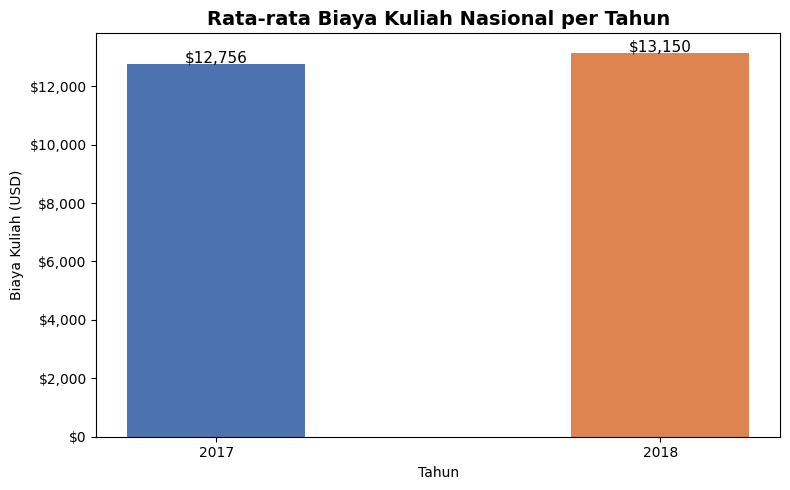

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(
    rollup["year"].astype(str),
    rollup["Avg Tuition Cost"],
    color=["#4C72B0", "#DD8452"],
    width=0.4
)
ax.set_title("Rata-rata Biaya Kuliah Nasional per Tahun", fontsize=14, fontweight="bold")
ax.set_xlabel("Tahun")
ax.set_ylabel("Biaya Kuliah (USD)")
ax.yaxis.set_major_formatter(mticker.StrMethodFormatter("${x:,.0f}"))
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            f"${bar.get_height():,.0f}", ha="center", fontsize=11)

# Insight
selisih = rollup["Avg Tuition Cost"].iloc[1] - rollup["Avg Tuition Cost"].iloc[0]
arah = "naik" if selisih > 0 else "turun"
print(f"Insight: Biaya kuliah {arah} sebesar ${abs(selisih):,.0f} dari 2017 ke 2018")

plt.tight_layout()
# plt.savefig("data/viz_1_tuition_per_year.png", dpi=150)
plt.show()

Insight: State RI memiliki completion rate tertinggi sebesar 63.5%


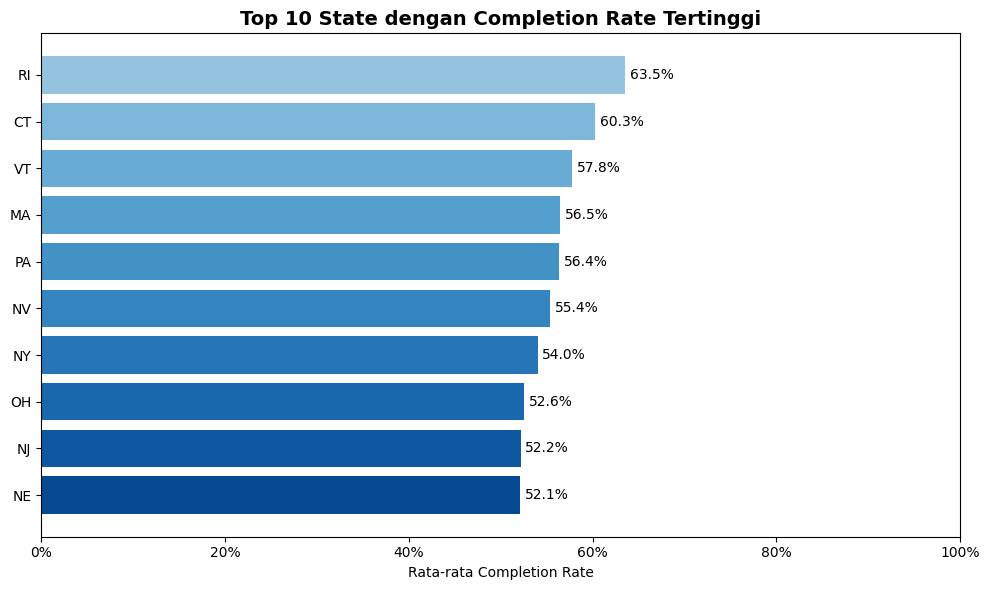

In [ ]:
result_rank = cube.query(
    m["Avg Completion Rate"],
    m["Avg Tuition Cost"],
    m["contributors.COUNT"],
    levels=[h["state"]["state"]]
).reset_index()
result_rank = result_rank.sort_values("Avg Completion Rate", ascending=False).head(10)

fig, ax = plt.subplots(figsize=(10, 6))
colors = plt.cm.Blues(np.linspace(0.4, 0.9, len(result_rank)))
bars = ax.barh(result_rank["state"], result_rank["Avg Completion Rate"], color=colors)
ax.set_title("Top 10 State dengan Completion Rate Tertinggi", fontsize=14, fontweight="bold")
ax.set_xlabel("Rata-rata Completion Rate")
ax.set_xlim(0, 1)
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.invert_yaxis()
for bar in bars:
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
            f"{bar.get_width():.1%}", va="center", fontsize=10)

# Insight
top1 = result_rank.iloc[0]
print(f"Insight: State {top1['state']} memiliki completion rate tertinggi sebesar {top1['Avg Completion Rate']:.1%}")

plt.tight_layout()
# plt.savefig("data/viz_2_top10_completion.png", dpi=150)
plt.show()

UT: naik 305 mahasiswa dari 2017 ke 2018
NH: naik 354 mahasiswa dari 2017 ke 2018
AZ: turun 44 mahasiswa dari 2017 ke 2018
MD: turun 52 mahasiswa dari 2017 ke 2018
CA: turun 28 mahasiswa dari 2017 ke 2018


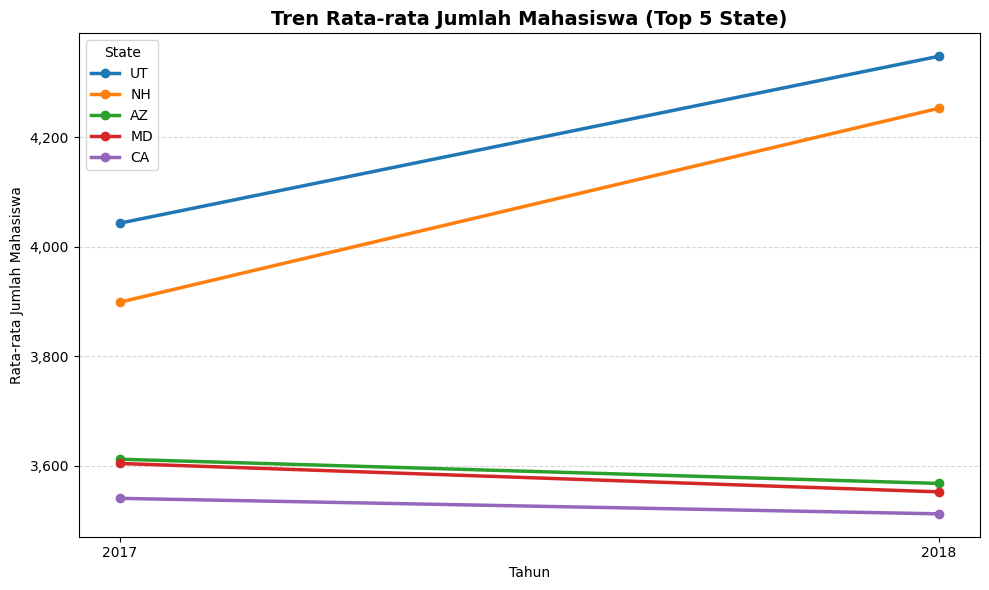

In [ ]:
result_trend = cube.query(
    m["Avg Student Size"],
    levels=[h["state"]["state"], h["year"]["year"]]
).reset_index()

top5 = result_trend.groupby("state")["Avg Student Size"].mean()\
       .sort_values(ascending=False).head(5).index.tolist()

fig, ax = plt.subplots(figsize=(10, 6))
for state in top5:
    data = result_trend[result_trend["state"] == state]
    ax.plot(data["year"].astype(str), data["Avg Student Size"],
            marker="o", linewidth=2.5, label=state)

ax.set_title("Tren Rata-rata Jumlah Mahasiswa (Top 5 State)", fontsize=14, fontweight="bold")
ax.set_xlabel("Tahun")
ax.set_ylabel("Rata-rata Jumlah Mahasiswa")
ax.yaxis.set_major_formatter(mticker.StrMethodFormatter("{x:,.0f}"))
ax.legend(title="State")
ax.grid(axis="y", linestyle="--", alpha=0.5)

# Insight
for state in top5:
    data = result_trend[result_trend["state"] == state].sort_values("year")
    delta = data["Avg Student Size"].iloc[-1] - data["Avg Student Size"].iloc[0]
    arah = "naik" if delta > 0 else "turun"
    print(f"{state}: {arah} {abs(delta):,.0f} mahasiswa dari 2017 ke 2018")

plt.tight_layout()
# plt.savefig("data/viz_3_trend_student.png", dpi=150)
plt.show()

Insight: Korelasi biaya kuliah vs completion rate = 0.805


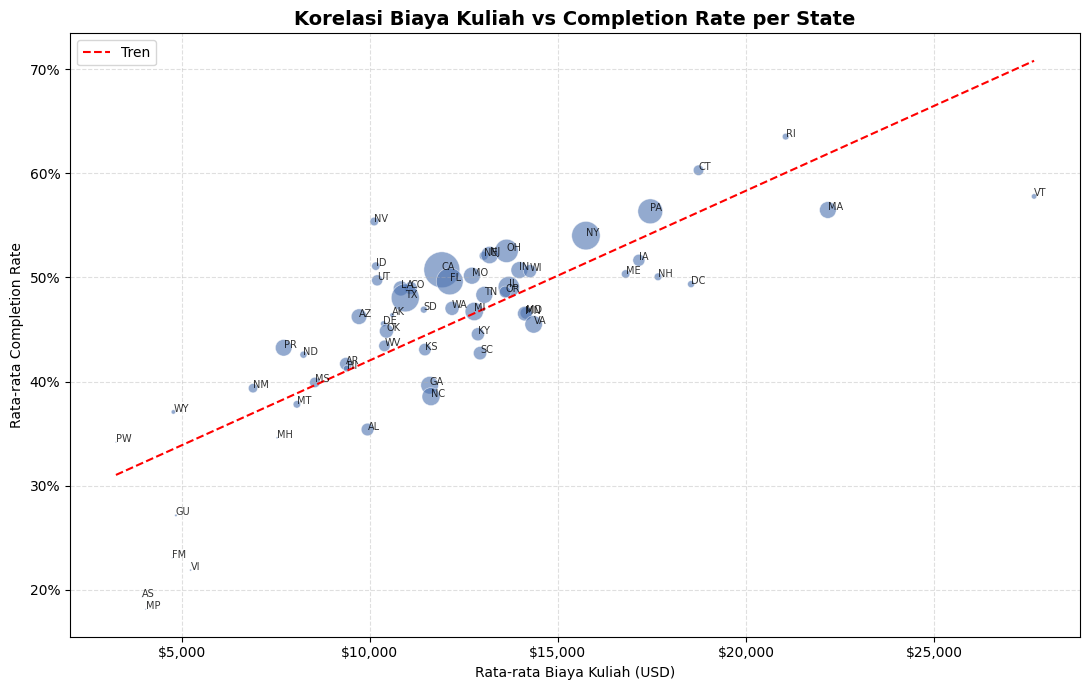

In [ ]:
result_corr = cube.query(
    m["Avg Completion Rate"],
    m["Avg Tuition Cost"],
    m["contributors.COUNT"],
    levels=[h["state"]["state"]]
).reset_index()

fig, ax = plt.subplots(figsize=(11, 7))
scatter = ax.scatter(
    result_corr["Avg Tuition Cost"],
    result_corr["Avg Completion Rate"],
    s=result_corr["contributors.COUNT"] * 0.5,
    alpha=0.6, color="#4C72B0", edgecolors="white", linewidth=0.5
)
for _, row in result_corr.iterrows():
    ax.annotate(row["state"],
                (row["Avg Tuition Cost"], row["Avg Completion Rate"]),
                fontsize=7, alpha=0.8)

# Garis tren
z = np.polyfit(result_corr["Avg Tuition Cost"], result_corr["Avg Completion Rate"], 1)
p = np.poly1d(z)
x_line = np.linspace(result_corr["Avg Tuition Cost"].min(),
                     result_corr["Avg Tuition Cost"].max(), 100)
ax.plot(x_line, p(x_line), "r--", linewidth=1.5, label="Tren")

ax.set_title("Korelasi Biaya Kuliah vs Completion Rate per State",
             fontsize=14, fontweight="bold")
ax.set_xlabel("Rata-rata Biaya Kuliah (USD)")
ax.set_ylabel("Rata-rata Completion Rate")
ax.xaxis.set_major_formatter(mticker.StrMethodFormatter("${x:,.0f}"))
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.legend()
ax.grid(linestyle="--", alpha=0.4)

# Insight korelasi
corr = result_corr["Avg Tuition Cost"].corr(result_corr["Avg Completion Rate"])
print(f"Insight: Korelasi biaya kuliah vs completion rate = {corr:.3f}")

plt.tight_layout()
# plt.savefig("data/viz_4_korelasi.png", dpi=150)
plt.show()

Insight: State RI paling kompetitif dengan admission rate hanya 66.0%


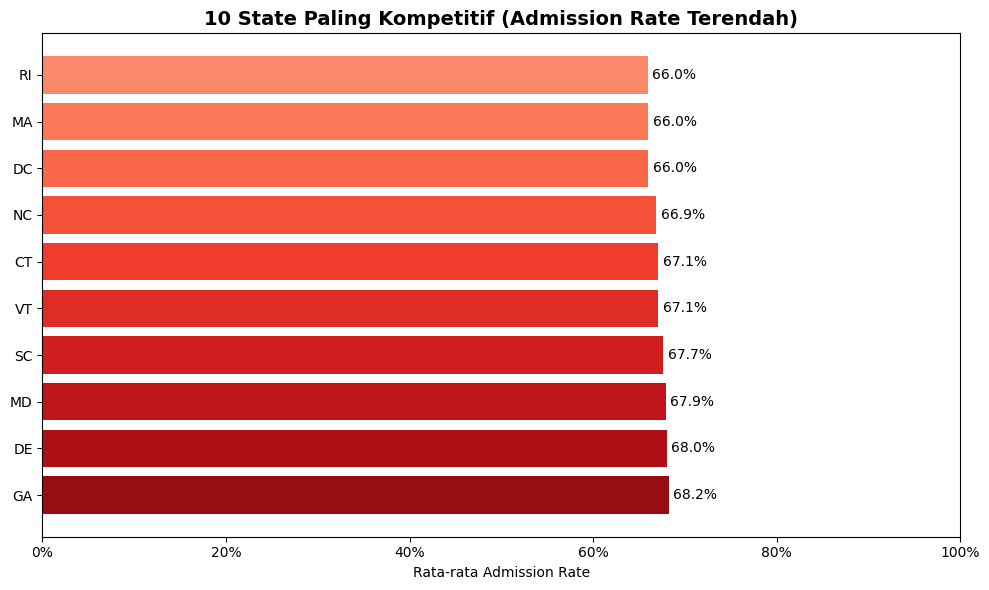

In [ ]:
result_adm = cube.query(
    m["Avg Admission Rate"],
    m["Avg Student Size"],
    levels=[h["state"]["state"]]
).reset_index()
result_adm = result_adm.sort_values("Avg Admission Rate").head(10)

fig, ax = plt.subplots(figsize=(10, 6))
colors = plt.cm.Reds(np.linspace(0.4, 0.9, len(result_adm)))
bars = ax.barh(result_adm["state"], result_adm["Avg Admission Rate"], color=colors)
ax.set_title("10 State Paling Kompetitif (Admission Rate Terendah)",
             fontsize=14, fontweight="bold")
ax.set_xlabel("Rata-rata Admission Rate")
ax.set_xlim(0, 1)
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.invert_yaxis()
for bar in bars:
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
            f"{bar.get_width():.1%}", va="center", fontsize=10)

# Insight
bot1 = result_adm.iloc[0]
print(f"Insight: State {bot1['state']} paling kompetitif dengan admission rate hanya {bot1['Avg Admission Rate']:.1%}")

plt.tight_layout()
plt.savefig("data/viz_5_admission.png", dpi=150)
plt.show()

In [ ]:
# Lihat semua state yang ada di data
states_list = df_clean[["state"]].drop_duplicates().sort_values("state").reset_index(drop=True)
print(f"Total state: {len(states_list)}")
print(states_list.to_string())

Total state: 59
   state
0     AK
1     AL
2     AR
3     AS
4     AZ
5     CA
6     CO
7     CT
8     DC
9     DE
10    FL
11    FM
12    GA
13    GU
14    HI
15    IA
16    ID
17    IL
18    IN
19    KS
20    KY
21    LA
22    MA
23    MD
24    ME
25    MH
26    MI
27    MN
28    MO
29    MP
30    MS
31    MT
32    NC
33    ND
34    NE
35    NH
36    NJ
37    NM
38    NV
39    NY
40    OH
41    OK
42    OR
43    PA
44    PR
45    PW
46    RI
47    SC
48    SD
49    TN
50    TX
51    UT
52    VA
53    VI
54    VT
55    WA
56    WI
57    WV
58    WY


In [ ]:
state_names = {
    "AK": "Alaska", "AL": "Alabama", "AR": "Arkansas", "AS": "American Samoa",
    "AZ": "Arizona", "CA": "California", "CO": "Colorado", "CT": "Connecticut",
    "DC": "District of Columbia", "DE": "Delaware", "FL": "Florida", "FM": "Micronesia",
    "GA": "Georgia", "GU": "Guam", "HI": "Hawaii", "IA": "Iowa",
    "ID": "Idaho", "IL": "Illinois", "IN": "Indiana", "KS": "Kansas",
    "KY": "Kentucky", "LA": "Louisiana", "MA": "Massachusetts", "MD": "Maryland",
    "ME": "Maine", "MH": "Marshall Islands", "MI": "Michigan", "MN": "Minnesota",
    "MO": "Missouri", "MP": "Northern Mariana Islands", "MS": "Mississippi", "MT": "Montana",
    "NC": "North Carolina", "ND": "North Dakota", "NE": "Nebraska", "NH": "New Hampshire",
    "NJ": "New Jersey", "NM": "New Mexico", "NV": "Nevada", "NY": "New York",
    "OH": "Ohio", "OK": "Oklahoma", "OR": "Oregon", "PA": "Pennsylvania",
    "PR": "Puerto Rico", "PW": "Palau", "RI": "Rhode Island", "SC": "South Carolina",
    "SD": "South Dakota", "TN": "Tennessee", "TX": "Texas", "UT": "Utah",
    "VA": "Virginia", "VI": "Virgin Islands", "VT": "Vermont", "WA": "Washington",
    "WI": "Wisconsin", "WV": "West Virginia", "WY": "Wyoming"
}

# Tampilkan state yang ada di data beserta nama lengkapnya
df_states = df_clean[["state"]].drop_duplicates().sort_values("state").reset_index(drop=True)
df_states["nama_lengkap"] = df_states["state"].map(state_names)
print(df_states.to_string())

   state              nama_lengkap
0     AK                    Alaska
1     AL                   Alabama
2     AR                  Arkansas
3     AS            American Samoa
4     AZ                   Arizona
5     CA                California
6     CO                  Colorado
7     CT               Connecticut
8     DC      District of Columbia
9     DE                  Delaware
10    FL                   Florida
11    FM                Micronesia
12    GA                   Georgia
13    GU                      Guam
14    HI                    Hawaii
15    IA                      Iowa
16    ID                     Idaho
17    IL                  Illinois
18    IN                   Indiana
19    KS                    Kansas
20    KY                  Kentucky
21    LA                 Louisiana
22    MA             Massachusetts
23    MD                  Maryland
24    ME                     Maine
25    MH          Marshall Islands
26    MI                  Michigan
27    MN            